In [12]:
from ase import io
from ase.eos import EquationOfState
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("/home/jvc/ZnO_database/mpl_themes/jvc.mplstyle")


In [2]:
paths = [f for f in Path("/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS").iterdir()]
print(paths[:10])

[PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.52-1.67-111.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.00-1.70-222.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.52-1.54-113.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.52-1.64-221.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.07-1.70-113.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.52-1.57-112.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.39-1.67-222.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.32-1.64-213.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.45-1.51-312.out'), PosixPath('/home/jvc/ZnO_database/scripts/LDA_000_OUTPUTS/ZnO-3.07-1.44-312.out')]


In [14]:
volumes = np.array([io.read(file).get_volume() / 2 for file in paths if "-111.out" in file.name ])
energies = np.array([io.read(file).get_total_energy() / 2 for file in paths if "-111.out" in file.name ])


<h2>Murnaghan equation</h2>

$$

E(V) = E_0 - \frac{B_0 V_0}{B' - 1} + \frac{B_0 V}{B'} \left [\frac{(V_0/V)^{B'}}{B' - 1} + 1\right]

$$

onde $E_0$, $V_0$ e $B_0$ são a energia total, o volume por unidade de fórmula de ZnO e o módulo de compressibilidade a pressão zero (P), respectivamente, e assume-se que $B' = dB/dP$ seja constante.


In [7]:
from ase.units import kJ

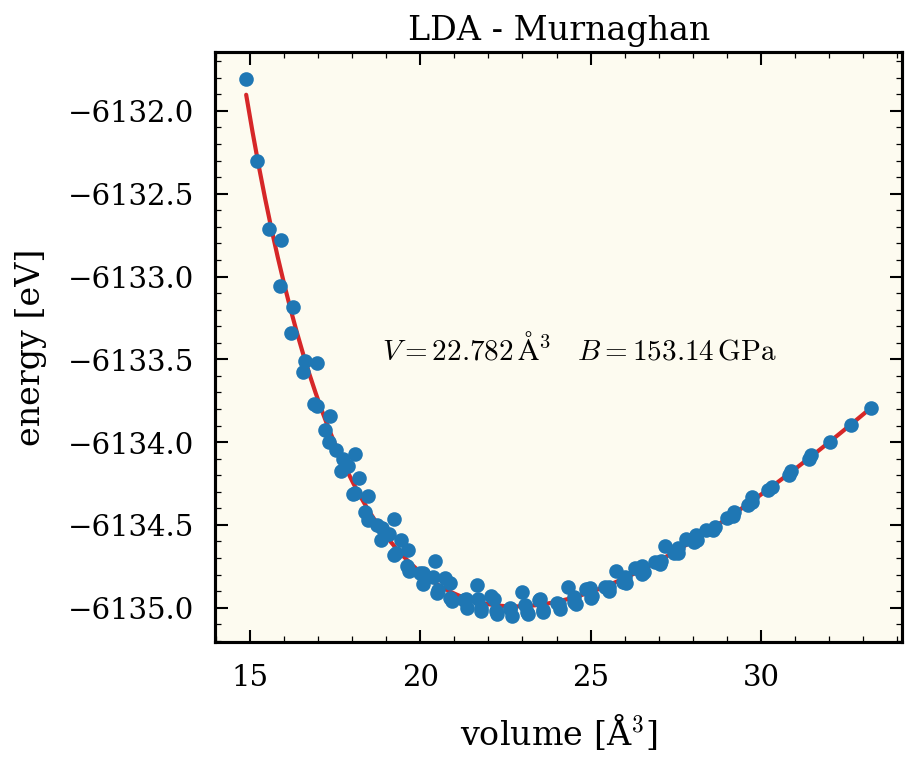

In [22]:
eos = EquationOfState(volumes, energies, eos="murnaghan")
v0, e0, B = eos.fit()
B_GPa = B / kJ * 1.0e24
fig, ax = plt.subplots(dpi=150, layout="constrained")
ax = eos.plot(show=False,ax=ax)
ax.set_title("LDA - Murnaghan")
ax.text(
    x=volumes.min()+4,y=-6133.5, s=fr"$V = {v0:.3f}\,\mathrm{{\AA^3}}\quad B = {B_GPa:.2f}\,\mathrm{{GPa}}$"
)
plt.show()

<h2> Birch–Murnaghan </h2>

$$ E(V)=E_{0}+{\frac {9V_{0}B_{0}}{16}}\left\{\left[\left({\frac {V_{0}}{V}}\right)^{2/3}-1\right]^{3}B_{0}^{\prime }+\left[\left({\frac {V_{0}}{V}}\right)^{2/3}-1\right]^{2}\left[6-4\left({\frac {V_{0}}{V}}\right)^{2/3}\right]\right\} $$

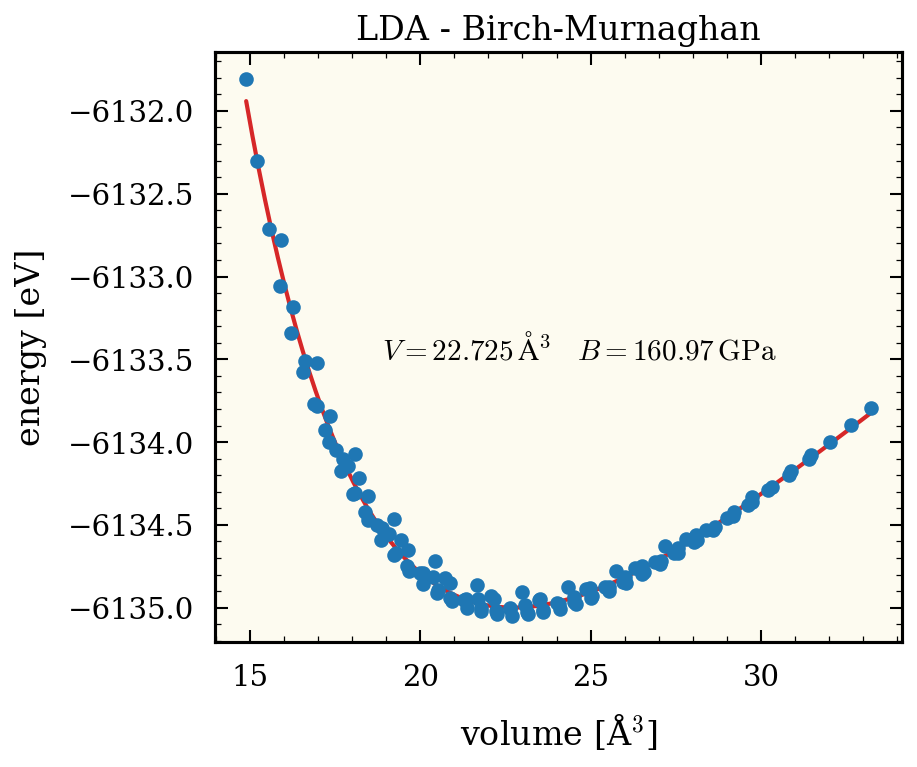

In [25]:
eos = EquationOfState(volumes, energies, eos="birchmurnaghan")
v0, e0, B = eos.fit()
B_GPa = B / kJ * 1.0e24
fig, ax = plt.subplots(dpi=150, layout="constrained")
ax = eos.plot(show=False,ax=ax)
ax.set_title("LDA - Birch-Murnaghan")
ax.text(
    x=volumes.min()+4,y=-6133.5, s=fr"$V = {v0:.3f}\,\mathrm{{\AA^3}}\quad B = {B_GPa:.2f}\,\mathrm{{GPa}}$"
)
plt.show()

---